In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_df = pd.read_csv(
    RAW_DATA_DIR / "application_train.csv"
)

competition_df = pd.read_csv(
    RAW_DATA_DIR / "application_test.csv"
)
description_df = pd.read_csv(
    RAW_DATA_DIR / "HomeCredit_columns_description.csv",
    encoding="latin-1"
)


In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

app_descriptions = description_df.loc[
    description_df["Table"] == "application_{train|test}.csv",
    ["Row", "Description", "Special"]
].copy()

app_descriptions = app_descriptions.rename(
    columns={"Row": "Feature"}
)

column_summary = pd.DataFrame({
    "Feature": train_df.columns,
    "Data Type": train_df.dtypes.astype(str).values,
    "Missing %": (
        train_df.isna().mean() * 100
    ).round(2).values,
    "Unique Values": train_df.nunique(
        dropna=False
    ).values
})

column_overview = column_summary.merge(
    app_descriptions,
    on="Feature",
    how="left"
)

column_overview = column_overview[
    [
        "Feature",
        "Data Type",
        "Missing %",
        "Unique Values",
        "Description",
        "Special"
    ]
]

display(column_overview)

,Feature,Data Type,Missing %,Unique Values,Description,Special
0,SK_ID_CURR,int64,0.00,307511,ID of loan in our sample,NaN
1,TARGET,int64,0.00,2,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",NaN
2,NAME_CONTRACT_TYPE,str,0.00,2,Identification if loan is cash or revolving,NaN
3,CODE_GENDER,str,0.00,3,Gender of the client,NaN
4,FLAG_OWN_CAR,str,0.00,2,Flag if the client owns a car,NaN
5,FLAG_OWN_REALTY,str,0.00,2,Flag if client owns a house or flat,NaN
6,CNT_CHILDREN,int64,0.00,15,Number of children the client has,NaN
7,AMT_INCOME_TOTAL,float64,0.00,2548,Income of the client,NaN
8,AMT_CREDIT,float64,0.00,5603,Credit amount of the loan,NaN
9,AMT_ANNUITY,float64,0.00,13673,Loan annuity,NaN


In [3]:
def search_descriptions(keyword):
    mask = (
        column_overview["Feature"]
        .str.contains(keyword, case=False, na=False)
        |
        column_overview["Description"]
        .str.contains(keyword, case=False, na=False)
    )

    return column_overview.loc[mask]

In [4]:
pd.reset_option("display.max_rows")
pd.reset_option("display.max_colwidth")
pd.reset_option("display.width")

In [5]:
train_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
train_df.shape

(307511, 122)

In [7]:
train_df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=122)

In [8]:
train_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [9]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [10]:
train_df.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [11]:
train_df["TARGET"].value_counts(normalize = True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_MEDI            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MODE               0.593767
BASEMENTAREA_MODE           0.585160
BASEMENTAREA_MEDI           0.585160
BASEMENTAREA_AVG            0.585160
EXT_SOURCE_1                0.563811
NONLIVINGAREA_MODE          0.551792
NONLIVINGAREA_AVG           0.551792
NONLIVINGAREA_MEDI          0.551792
E

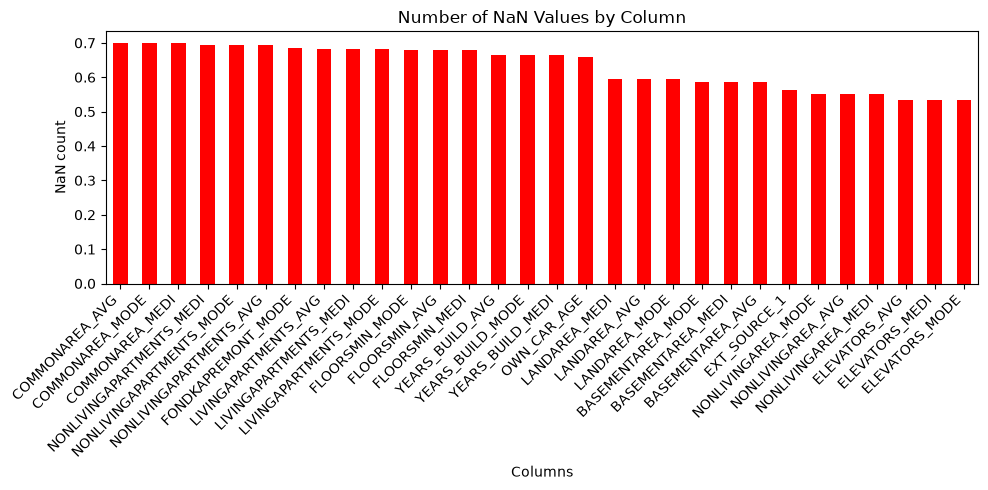

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 122, dtype: float64


In [12]:
missing_values = train_df.isna().mean().sort_values(ascending=False)
print(missing_values.head(30))

# NaN values for each column


missing_values.head(30).plot(
    kind="bar",
    figsize=(10, 5),
    color="red"
)

plt.title("Number of NaN Values by Column")
plt.xlabel("Columns")
plt.ylabel("NaN count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(train_df.isna().mean()*100)

In [13]:
train_df["DAYS_BIRTH"].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

In [14]:
train_df["DAYS_EMPLOYED"].value_counts().head()

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
Name: count, dtype: int64

In [15]:
train_df["AMT_INCOME_TOTAL"].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [16]:
display(search_descriptions("AMT"))

,Feature,Data Type,Missing %,Unique Values,Description,Special
7,AMT_INCOME_TOTAL,float64,0.00,2548,Income of the client,NaN
8,AMT_CREDIT,float64,0.00,5603,Credit amount of the loan,NaN
9,AMT_ANNUITY,float64,0.00,13673,Loan annuity,NaN
10,AMT_GOODS_PRICE,float64,0.09,1003,For consumer loans it is the price of the good...,NaN
116,AMT_REQ_CREDIT_BUREAU_HOUR,float64,13.50,6,Number of enquiries to Credit Bureau about the...,NaN
117,AMT_REQ_CREDIT_BUREAU_DAY,float64,13.50,10,Number of enquiries to Credit Bureau about the...,NaN
118,AMT_REQ_CREDIT_BUREAU_WEEK,float64,13.50,10,Number of enquiries to Credit Bureau about the...,NaN
119,AMT_REQ_CREDIT_BUREAU_MON,float64,13.50,25,Number of enquiries to Credit Bureau about the...,NaN
120,AMT_REQ_CREDIT_BUREAU_QRT,float64,13.50,12,Number of enquiries to Credit Bureau about the...,NaN
121,AMT_REQ_CREDIT_BUREAU_YEAR,float64,13.50,26,Number of enquiries to Credit Bureau about the...,NaN


In [17]:
display(search_descriptions("day"))

,Feature,Data Type,Missing %,Unique Values,Description,Special
1,TARGET,int64,0.00,2,Target variable (1 - client with payment diffi...,NaN
17,DAYS_BIRTH,int64,0.00,17460,Client's age in days at the time of application,time only relative to the application
18,DAYS_EMPLOYED,int64,0.00,12574,How many days before the application the perso...,time only relative to the application
19,DAYS_REGISTRATION,float64,0.00,15688,How many days before the application did clien...,time only relative to the application
20,DAYS_ID_PUBLISH,int64,0.00,6168,How many days before the application did clien...,time only relative to the application
32,WEEKDAY_APPR_PROCESS_START,str,0.00,7,On which day of the week did the client apply ...,NaN
91,OBS_30_CNT_SOCIAL_CIRCLE,float64,0.33,34,How many observation of client's social surrou...,NaN
92,DEF_30_CNT_SOCIAL_CIRCLE,float64,0.33,11,How many observation of client's social surrou...,NaN
93,OBS_60_CNT_SOCIAL_CIRCLE,float64,0.33,34,How many observation of client's social surrou...,NaN
94,DEF_60_CNT_SOCIAL_CIRCLE,float64,0.33,10,How many observation of client's social surrou...,NaN


In [18]:
display(search_descriptions("credit"))

,Feature,Data Type,Missing %,Unique Values,Description,Special
8,AMT_CREDIT,float64,0.0,5603,Credit amount of the loan,NaN
116,AMT_REQ_CREDIT_BUREAU_HOUR,float64,13.5,6,Number of enquiries to Credit Bureau about the...,NaN
117,AMT_REQ_CREDIT_BUREAU_DAY,float64,13.5,10,Number of enquiries to Credit Bureau about the...,NaN
118,AMT_REQ_CREDIT_BUREAU_WEEK,float64,13.5,10,Number of enquiries to Credit Bureau about the...,NaN
119,AMT_REQ_CREDIT_BUREAU_MON,float64,13.5,25,Number of enquiries to Credit Bureau about the...,NaN
120,AMT_REQ_CREDIT_BUREAU_QRT,float64,13.5,12,Number of enquiries to Credit Bureau about the...,NaN
121,AMT_REQ_CREDIT_BUREAU_YEAR,float64,13.5,26,Number of enquiries to Credit Bureau about the...,NaN


In [19]:
train_df.groupby("TARGET")[
    "AMT_CREDIT"
].median()

TARGET
0    517788.0
1    497520.0
Name: AMT_CREDIT, dtype: float64

In [20]:
pd.crosstab(
    train_df["NAME_INCOME_TYPE"],
    train_df["TARGET"],
    normalize="index"
)

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,1.000000,0.000000
Commercial associate,0.925157,0.074843
Maternity leave,0.600000,0.400000
Pensioner,0.946136,0.053864
State servant,0.942450,0.057550
Student,1.000000,0.000000
Unemployed,0.636364,0.363636
Working,0.904115,0.095885


Main findings:
- TARGET is imbalanced.
- Several numerical features contain missing values.
- DAYS_EMPLOYED contains a sentinel value.
- EXT_SOURCE variables appear promising.
- Some numerical variables are strongly skewed.
- Missing values must be handled in a Pipeline.